# MassSpecGym Processing Check (gems_a_test)
This notebook verifies that MassSpecGym data is processed correctly using `configs/gems_a_test.py`.

In [15]:
import torch

# Show what each mode sets (great for "max-autotune" vs "max-autotune-no-cudagraphs")
import torch._inductor as inductor

print(inductor.list_mode_options())

# List all backend (Inductor) options available to pass via torch.compile(..., options=...)
print(inductor.list_options())

{'default': {}, 'lite': {'fallback_by_default': True, 'selective_decompose': True, 'reorder_for_peak_memory': False, 'reorder_for_compute_comm_overlap': False, 'triton.reorder_for_reducing_graph_partitions': False, 'use_pre_grad_passes': False, 'use_joint_graph_passes': False, 'use_post_grad_passes': False, 'use_dce': False, 'allow_buffer_reuse': False}, 'reduce-overhead': {'triton.cudagraphs': True}, 'max-autotune-no-cudagraphs': {'max_autotune': True, 'coordinate_descent_tuning': True}, 'max-autotune': {'max_autotune': True, 'triton.cudagraphs': True, 'coordinate_descent_tuning': True}}
['TYPE_CHECKING', 'inplace_padding', 'can_inplace_pad_graph_input', 'enable_auto_functionalized_v2', 'debug', 'disable_progress', 'verbose_progress', 'worker_log_path', 'precompilation_timeout_seconds', 'fx_graph_cache', 'remote_gemm_autotune_cache', 'fx_graph_remote_cache', 'bundle_triton_into_fx_graph_cache', 'non_blocking_remote_cache_write', 'autotune_local_cache', 'autotune_remote_cache', 'bundle

In [2]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pathlib import Path
import importlib.util
import json
import csv

import numpy as np
import tensorflow as tf

import input_pipeline as ip

ROOT = Path("..").resolve()
CFG_PATH = ROOT / "configs" / "gems_a_test.py"

# Load config
spec = importlib.util.spec_from_file_location("cfg", CFG_PATH)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
cfg = mod.get_config()
cfg.tfrecord_dir = "../" + cfg.tfrecord_dir

print("Config loaded:", CFG_PATH)
print("tfrecord_dir:", cfg.tfrecord_dir)

2026-02-05 09:14:38.333239: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 09:14:38.364926: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 09:14:39.222781: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm

Config loaded: /home/wuhao/spectra-learning/configs/gems_a_test.py
tfrecord_dir: ../data/gems_peaklist_tfrecord


In [3]:
# Build the datamodule (loads/validates TFRecords if present)
module = ip.TfLightningDataModule(cfg, seed=int(cfg.seed))

print("MassSpec sizes from metadata:")
print("  train:", module.info["massspec_train_size"])
print("  val:", module.info["massspec_val_size"])
print("  test:", module.info["massspec_test_size"])

MassSpec sizes from metadata:
  train: 194119
  val: 19429
  test: 17556


In [4]:
# Verify TSV fold counts match metadata
meta_path = Path(module.info["tfrecord_dir"]) / "metadata.json"
metadata = json.loads(meta_path.read_text())

counts = {"train": 0, "val": 0, "test": 0}
with (ROOT / "data" / "data" / "MassSpecGym.tsv").open() as f:
    reader = csv.DictReader(f, delimiter="	")
    for row in reader:
        counts[row["fold"]] += 1

print("TSV counts:", counts)
print(
    "Metadata counts:",
    {
        "train": metadata["massspec_train_size"],
        "val": metadata["massspec_val_size"],
        "test": metadata["massspec_test_size"],
    },
)

TSV counts: {'train': 194119, 'val': 19429, 'test': 17556}
Metadata counts: {'train': 194119, 'val': 19429, 'test': 17556}


In [5]:
# Inspect one raw TFRecord example (fingerprint should be present)
file_path = module.massspec_train_files[0]
raw_ds = tf.data.TFRecordDataset([file_path], compression_type="GZIP")
for raw in raw_ds.take(1):
    ex = tf.train.Example()
    ex.ParseFromString(raw.numpy())
    feats = ex.features.feature
    print("raw mz len:", len(feats["mz"].float_list.value))
    print("raw intensity len:", len(feats["intensity"].float_list.value))
    print("raw fingerprint len:", len(feats["fingerprint"].int64_list.value))
    print(
        "fingerprint unique values:",
        sorted(set(feats["fingerprint"].int64_list.value))[:5],
    )

raw mz len: 128
raw intensity len: 128
raw fingerprint len: 1024
fingerprint unique values: [0, 1]


2026-02-05 09:14:44.141402: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-05 09:14:44.142627: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
# Verify processed batch (tokenization + masking) includes fingerprint in probe dataset
probe_ds = module.build_massspec_probe_dataset("massspec_train", seed=123)
batch = next(probe_ds.take(1).as_numpy_iterator())

print("batch keys:", batch.keys())
print("token_ids shape:", batch["token_ids"].shape)
print("segment_ids shape:", batch["segment_ids"].shape)
print("masked_token_ids shape:", batch["masked_token_ids"].shape)
print("mlm_mask shape:", batch["mlm_mask"].shape)
print("fingerprint shape:", batch["fingerprint"].shape)

vocab = module.info["vocab_size"]
print("token_ids min/max:", batch["token_ids"].min(), batch["token_ids"].max())
print("vocab_size:", vocab)
print("token_ids within vocab:", batch["token_ids"].max() < vocab)

batch keys: dict_keys(['rt', 'precursor_mz', 'fingerprint', 'token_ids', 'segment_ids', 'masked_token_ids', 'mlm_mask'])
token_ids shape: (512, 128)
segment_ids shape: (512, 128)
masked_token_ids shape: (512, 128)
mlm_mask shape: (512, 128)
fingerprint shape: (512, 1024)
token_ids min/max: 0 1036
vocab_size: 1037
token_ids within vocab: True


2026-02-05 09:14:44.590422: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


In [7]:
batch["masked_token_ids"][0]

array([   1,  129, 1036,  250, 1027,    3, 1016,    3, 1015,    3, 1012,
          3, 1009,  158, 1007,  204, 1006,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0], dtype=int32)

In [8]:
batch["mlm_mask"][0]

array([False, False, False, False, False,  True, False,  True, False,
        True, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False]

In [6]:
# Sanity-check that standard MassSpec datasets do not include fingerprints
massspec_train_ds = module._build_massspec_train_dataset(seed=123)
train_batch = next(massspec_train_ds.take(1).as_numpy_iterator())
print("massspec train keys:", train_batch.keys())

massspec train keys: dict_keys(['rt', 'precursor_mz', 'token_ids', 'segment_ids', 'masked_token_ids', 'mlm_mask'])


## Visualize Raw MassSpecGym Spectra
Plots a few raw spectra directly from `data/data/MassSpecGym.tsv`.

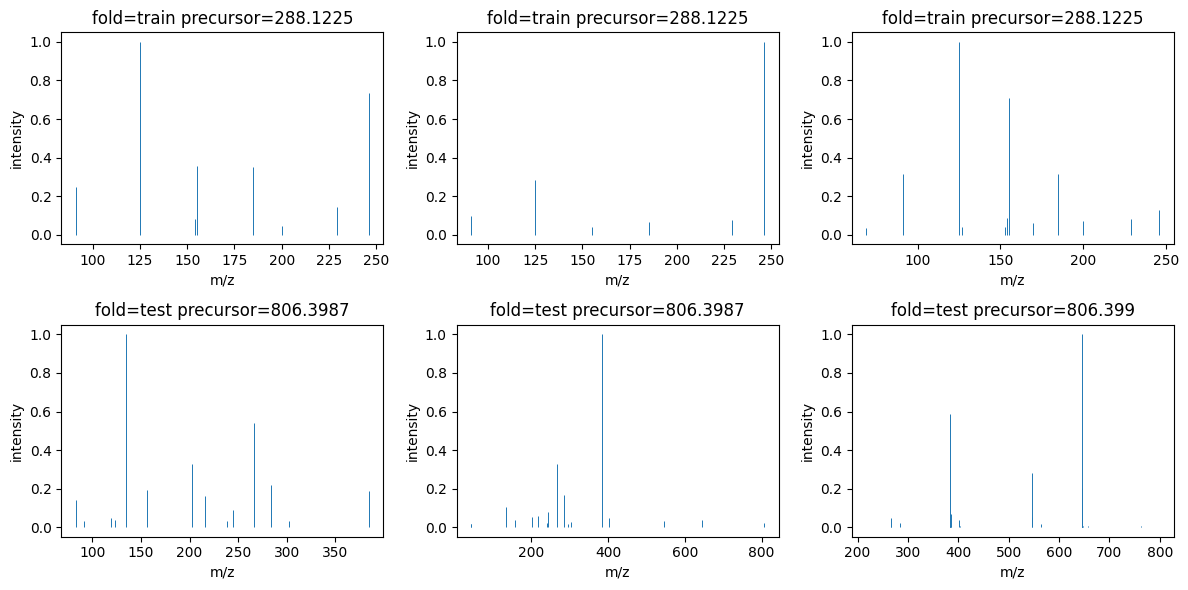

In [8]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
TSV_PATH = ROOT / "data" / "data" / "MassSpecGym.tsv"

# Load a few spectra rows
rows = []
with TSV_PATH.open() as f:
    reader = csv.DictReader(f, delimiter="	")
    for i, row in enumerate(reader):
        if i < 3:
            rows.append(row)
        if i >= 200 and len(rows) < 6:
            rows.append(row)
        if len(rows) >= 6:
            break

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=False, sharey=False)
axes = axes.flatten()

for ax, row in zip(axes, rows):
    mz = np.fromstring(row["mzs"], sep=",", dtype=np.float32)
    intensity = np.fromstring(row["intensities"], sep=",", dtype=np.float32)
    ax.vlines(mz, 0, intensity, color="#1f77b4", linewidth=0.7)
    ax.set_title(f"fold={row['fold']} precursor={row['precursor_mz']}")
    ax.set_xlabel("m/z")
    ax.set_ylabel("intensity")

plt.tight_layout()
plt.show()

## Compare Raw vs Tokenized (MassSpecGym + GeMS)
Compares raw spectra from TFRecords with detokenized spectra produced by the pipeline.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def _build_raw_and_tokenized_ds(files, include_fingerprint: bool):
    parse_fn = (
        ip._parse_example_with_fingerprint if include_fingerprint else ip._parse_example
    )
    ds = tf.data.TFRecordDataset(
        files,
        compression_type="GZIP",
        buffer_size=int(module.tfrecord_buffer_size),
        num_parallel_reads=tf.data.AUTOTUNE,
    )
    ds = ds.map(parse_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.filter(ip._filter_max_precursor_mz(module.max_precursor_mz))

    def add_raw_copy(example: dict) -> dict:
        example["raw_mz"] = example["mz"]
        example["raw_intensity"] = example["intensity"]
        return example

    ds = ds.map(add_raw_copy, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(
        ip._filter_peak_mz_range(
            ip._PEAK_MZ_MIN,
            ip._PEAK_MZ_MAX,
            ip._PRECURSOR_MZ_WINDOW,
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.map(
        ip._topk_peaks(ip._NUM_PEAKS_OUTPUT), num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.map(ip._compact_sort_peaks(), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(
        ip._strip_padding_and_tokenize(
            module.max_precursor_mz,
            module.intensity_scaling,
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.map(
        ip._build_single_spectrum_input(module.pair_sequence_length),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return ds


def _plot_raw_vs_tokenized(example: dict, title: str) -> None:
    raw_mz = example["raw_mz"]
    raw_intensity = example["raw_intensity"]
    raw_mask = raw_mz > 0
    raw_mz = raw_mz[raw_mask]
    raw_intensity = raw_intensity[raw_mask]
    raw_intensity = raw_intensity / raw_intensity.max()

    detok = ip.detokenize_spectrum(
        example["token_ids"],
        max_precursor_mz=module.max_precursor_mz,
        intensity_scaling=module.intensity_scaling,
    )
    tok_mz = detok["mz"]
    tok_intensity = detok["intensity"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    axes[0].vlines(raw_mz, 0, raw_intensity, color="tab:blue")
    axes[0].set_title(f"{title} raw (normalized)")
    axes[0].set_xlabel("m/z")
    axes[0].set_ylabel("intensity")

    axes[1].vlines(tok_mz, 0, tok_intensity, color="tab:orange")
    axes[1].set_title(f"{title} detokenized")
    axes[1].set_xlabel("m/z")

    plt.tight_layout()
    plt.show()


# MassSpecGym comparison
massspec_ds = _build_raw_and_tokenized_ds(
    module.massspec_train_files, include_fingerprint=True
)
massspec_ex = next(massspec_ds.take(1).as_numpy_iterator())
_plot_raw_vs_tokenized(massspec_ex, "MassSpecGym")

# GeMS comparison
gems_ds = _build_raw_and_tokenized_ds(
    module.gems_train_files, include_fingerprint=False
)
gems_ex = next(gems_ds.take(1).as_numpy_iterator())
_plot_raw_vs_tokenized(gems_ex, "GeMS")

## Precursor m/z Distribution (MassSpecGym)
Histogram over all MassSpecGym examples after the pipeline precursor filter.


count: 231104
min/max: 60.08104705810547 999.39599609375


2026-02-05 09:23:40.219169: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


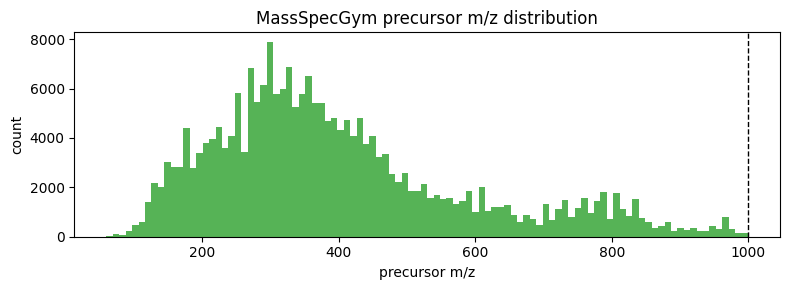

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

files = (
    module.massspec_train_files + module.massspec_val_files + module.massspec_test_files
)

precursor_ds = tf.data.TFRecordDataset(
    files,
    compression_type="GZIP",
    buffer_size=int(module.tfrecord_buffer_size),
    num_parallel_reads=tf.data.AUTOTUNE,
)
precursor_ds = precursor_ds.map(ip._parse_example, num_parallel_calls=tf.data.AUTOTUNE)
precursor_ds = precursor_ds.filter(ip._filter_max_precursor_mz(module.max_precursor_mz))
precursor_ds = precursor_ds.map(
    lambda ex: ex["precursor_mz"], num_parallel_calls=tf.data.AUTOTUNE
)
precursor_ds = precursor_ds.batch(8192)

chunks = []
for batch in precursor_ds.as_numpy_iterator():
    chunks.append(batch)
precursor = np.concatenate(chunks) if chunks else np.array([], dtype=np.float32)

print("count:", precursor.size)
print(
    "min/max:",
    float(precursor.min()) if precursor.size else None,
    float(precursor.max()) if precursor.size else None,
)

plt.figure(figsize=(8, 3))
plt.hist(precursor, bins=100, color="tab:green", alpha=0.8)
plt.axvline(module.max_precursor_mz, color="black", linestyle="--", linewidth=1)
plt.title("MassSpecGym precursor m/z distribution")
plt.xlabel("precursor m/z")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Precursor m/z Alignment Check (MassSpecGym)
Compares raw TSV precursor m/z values to TFRecords, then verifies tokenized precursor IDs.


In [ ]:
import csv
import numpy as np
import tensorflow as tf

TSV_PATH = ROOT / "data" / "data" / "MassSpecGym.tsv"

raw_precursors = []
raw_folds = []
with TSV_PATH.open() as f:
    reader = csv.DictReader(f, delimiter="	")
    for row in reader:
        raw_precursors.append(float(row["precursor_mz"]))
        raw_folds.append(row["fold"])

raw_precursors = np.asarray(raw_precursors, dtype=np.float32)
raw_folds = np.asarray(raw_folds)


def _load_precursors_from_tfrecord(files, apply_filter: bool) -> np.ndarray:
    ds = tf.data.TFRecordDataset(
        files,
        compression_type="GZIP",
        buffer_size=int(module.tfrecord_buffer_size),
        num_parallel_reads=1,
    )
    ds = ds.map(ip._parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    if apply_filter:
        ds = ds.filter(ip._filter_max_precursor_mz(module.max_precursor_mz))
    ds = ds.map(lambda ex: ex["precursor_mz"], num_parallel_calls=tf.data.AUTOTUNE)
    options = tf.data.Options()
    options.experimental_deterministic = True
    ds = ds.with_options(options)
    ds = ds.batch(8192)
    chunks = [b for b in ds.as_numpy_iterator()]
    return np.concatenate(chunks)


def _compare_raw_vs_tfrecord(name: str, files, raw_split: np.ndarray) -> None:
    tf_split = _load_precursors_from_tfrecord(files, apply_filter=False)
    max_abs = np.max(np.abs(raw_split - tf_split))
    print(f"{name}: raw={raw_split.size} tfrecord={tf_split.size}")
    print(f"{name}: max abs diff={float(max_abs)}")
    print(f"{name}: allclose={bool(np.allclose(raw_split, tf_split, atol=1e-6))}")


def _check_token_alignment(name: str, files) -> None:
    ds = tf.data.TFRecordDataset(
        files,
        compression_type="GZIP",
        buffer_size=int(module.tfrecord_buffer_size),
        num_parallel_reads=1,
    )
    ds = ds.map(ip._parse_example, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.filter(ip._filter_max_precursor_mz(module.max_precursor_mz))

    def add_raw(example: dict) -> dict:
        example["precursor_raw"] = example["precursor_mz"]
        return example

    ds = ds.map(add_raw, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(
        ip._strip_padding_and_tokenize(
            module.max_precursor_mz, module.intensity_scaling
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.map(
        lambda ex: (ex["precursor_raw"], ex["precursor_mz"]),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    options = tf.data.Options()
    options.experimental_deterministic = True
    ds = ds.with_options(options)
    ds = ds.batch(8192)

    offset = int(module.info["precursor_offset"])
    mismatches = 0
    total = 0
    for raw_batch, token_batch in ds.as_numpy_iterator():
        expected = (
            np.floor(np.clip(raw_batch, 0.0, module.max_precursor_mz)).astype(np.int32)
            + offset
        )
        mismatches += int(np.count_nonzero(token_batch != expected))
        total += int(token_batch.size)
    print(f"{name}: token alignment mismatches={mismatches} of {total}")


raw_train = raw_precursors[raw_folds == "train"]
raw_val = raw_precursors[raw_folds == "val"]
raw_test = raw_precursors[raw_folds == "test"]

_compare_raw_vs_tfrecord("train", module.massspec_train_files, raw_train)
_compare_raw_vs_tfrecord("val", module.massspec_val_files, raw_val)
_compare_raw_vs_tfrecord("test", module.massspec_test_files, raw_test)

_check_token_alignment("train", module.massspec_train_files)
_check_token_alignment("val", module.massspec_val_files)
_check_token_alignment("test", module.massspec_test_files)

## MLM Mask Sanity Check
Ensures we do not mask `[CLS]` or `[PAD]` tokens and that mask counts never exceed maskable positions.

In [9]:
import numpy as np

# Use a batch from the GeMS train dataset
train_ds = module._build_gems_train_dataset(seed=123)
batch = next(train_ds.take(1).as_numpy_iterator())

pad_id = cfg.pad_token_id
cls_id = cfg.cls_token_id

mask = batch["mlm_mask"]
orig_ids = batch["token_ids"]

masked_on_pad = np.logical_and(mask, orig_ids == pad_id).sum()
masked_on_cls = np.logical_and(mask, orig_ids == cls_id).sum()

mask_counts = mask.sum(axis=1)
maskable = np.logical_and(orig_ids != pad_id, orig_ids != cls_id)
maskable_counts = maskable.sum(axis=1)

print("masked_on_pad:", int(masked_on_pad))
print("masked_on_cls:", int(masked_on_cls))
print("mask_count min/max:", int(mask_counts.min()), int(mask_counts.max()))
print("maskable_count min/max:", int(maskable_counts.min()), int(maskable_counts.max()))
print("any mask_count > maskable_count:", bool((mask_counts > maskable_counts).any()))

masked_on_pad: 0
masked_on_cls: 0
mask_count min/max: 4 36
maskable_count min/max: 14 120
any mask_count > maskable_count: False


## MLM Mask Diversity Check
Checks that masks vary within a batch, across batches, and across epochs.

In [11]:
import numpy as np

seed = 123
val_ds = module._build_gems_val_dataset(seed=seed)

iter1 = val_ds.as_numpy_iterator()
b1 = next(iter1)["mlm_mask"]
b2 = next(iter1)["mlm_mask"]

# Within-batch uniqueness
packed1 = np.packbits(b1, axis=1)
unique_masks = np.unique(packed1, axis=0).shape[0]
print("within batch unique masks:", unique_masks, "of", b1.shape[0])

# Across batches (same row index)
same_rows = np.all(b1 == b2, axis=1).sum()
print(
    "same masks at same row index across batch1/batch2:",
    int(same_rows),
    "of",
    b1.shape[0],
)

# Across epochs: new iterator on same dataset object
iter2 = val_ds.as_numpy_iterator()
b1_repeat = next(iter2)["mlm_mask"]
print(
    "same dataset object, first batch identical:", bool(np.array_equal(b1, b1_repeat))
)

# Across epochs: rebuild dataset with same seed
val_ds_epoch2 = module._build_gems_val_dataset(seed=seed)
b1_epoch2 = next(val_ds_epoch2.as_numpy_iterator())["mlm_mask"]
print("rebuild dataset, first batch identical:", bool(np.array_equal(b1, b1_epoch2)))

within batch unique masks: 512 of 512
same masks at same row index across batch1/batch2: 0 of 512
same dataset object, first batch identical: False
rebuild dataset, first batch identical: False
